<a href="https://colab.research.google.com/github/PALAK7890/Indian_Crime/blob/main/Crime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [39]:
url='https://raw.githubusercontent.com/PALAK7890/Indian_Crime/refs/heads/main/india_crime_dataset.csv'
df=pd.read_csv(url)
df.head()

,fir_number,date_reported,year,city,state,primary_crime_type,description,ipc_section,location_type,beat_zone,victim_age,victim_gender,arrest_made,case_status,severity,latitude,longitude
0,fir/pun/2015/4628,05 May 2015 04:56 PM,2015,Pune,Maharashtra,VEHICLE THEFT,Two Wheeler,IPC 379,Street,NaN,54.0,Male,NaN,CHARGE SHEETED,Low,18.602007,73.963196
1,FIR/AHM/2021/2730,08/02/2021 13:57:00,2021,Ahmedabad,Gujarat,VEHICLE THEFT,Car Theft,ipc 379,MARKET,23.0,63.0,MALE,No,Closed,Low,23.157595,72.713810
2,PUN-2017-4991,14/10/2017 16:19:00,2017,Pune,Maharashtra,COUNTERFEITING,fake currency,489A IPC,Residence,18.0,58.0,Male,no,Under Investigation,Low,18.425002,73.793409
3,FIR/MUM/2017/9525,13/08/17 13:11,2017,Mumbai,Maharashtra,FRAUD/CHEATING,UPI Fraud,IPC-420,ATM,8.0,26.0,FEMALE,yes,Pending Trial,Low,19.070575,72.949740
4,FIR92792023,28/10/2023 23:58:00,2023,Mumbai,Maharashtra,KIDNAPPING,Abduction for Ransom,IPC 363,SCHOOL,20.0,7.0,m,NaN,under investigation,High,18.927087,72.858727


In [40]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fir_number          60000 non-null  object 
 1   date_reported       60000 non-null  object 
 2   year                60000 non-null  int64  
 3   city                60000 non-null  object 
 4   state               60000 non-null  object 
 5   primary_crime_type  60000 non-null  object 
 6   description         60000 non-null  object 
 7   ipc_section         60000 non-null  object 
 8   location_type       56722 non-null  object 
 9   beat_zone           55784 non-null  float64
 10  victim_age          54616 non-null  float64
 11  victim_gender       53331 non-null  object 
 12  arrest_made         46136 non-null  object 
 13  case_status         55938 non-null  object 
 14  severity            60000 non-null  object 
 15  latitude            54036 non-null  float64
 16  long

In [41]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57000 entries, 0 to 59998
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fir_number          57000 non-null  object 
 1   date_reported       57000 non-null  object 
 2   year                57000 non-null  int64  
 3   city                57000 non-null  object 
 4   state               57000 non-null  object 
 5   primary_crime_type  57000 non-null  object 
 6   description         57000 non-null  object 
 7   ipc_section         57000 non-null  object 
 8   location_type       53910 non-null  object 
 9   beat_zone           53010 non-null  float64
 10  victim_age          51880 non-null  float64
 11  victim_gender       50652 non-null  object 
 12  arrest_made         43861 non-null  object 
 13  case_status         53136 non-null  object 
 14  severity            57000 non-null  object 
 15  latitude            51336 non-null  float64
 16  longitude

In [43]:
df.shape

(57000, 17)

<Axes: >

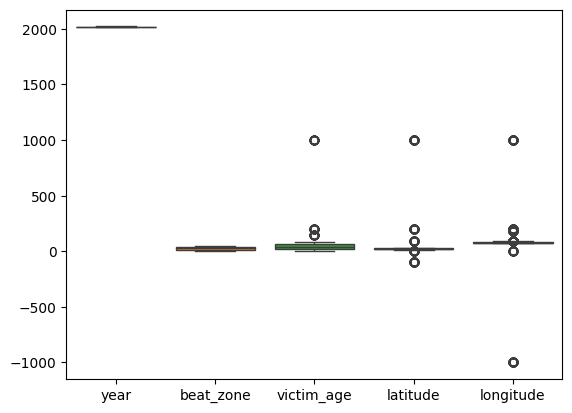

In [44]:
df_num=df.select_dtypes(include='number')
sns.boxplot(data=df_num)

<Axes: ylabel='victim_age'>

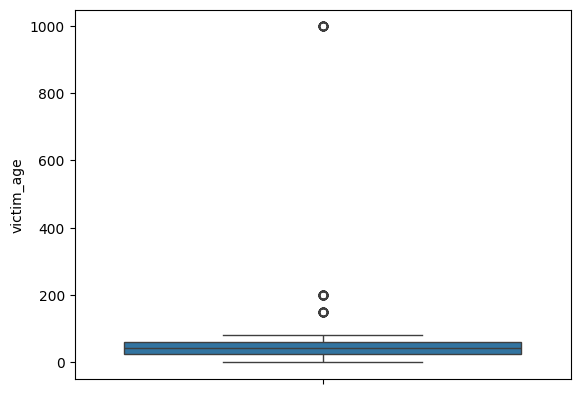

In [45]:
sns.boxplot(data=df['victim_age'])

In [46]:
df['victim_age'].describe()

,victim_age
count,51880.000000
mean,42.678065
std,31.461715
min,-1.000000
25%,23.000000
50%,42.000000
75%,61.000000
max,999.000000


In [47]:
lower=df['victim_age'].quantile(0.1)
higher=df['victim_age'].quantile(0.99)
df= df[(df['victim_age'] >= lower) & (df['victim_age'] <= higher)]
df['victim_age'].describe()

,victim_age
count,46851.000000
mean,45.573286
std,19.639851
min,12.000000
25%,29.000000
50%,46.000000
75%,63.000000
max,79.000000


In [48]:
df['longitude'].describe()

,longitude
count,42161.000000
mean,78.192003
std,51.334988
min,-999.000000
25%,73.926447
50%,77.301225
75%,80.235903
max,999.000000


In [57]:
print((df['longitude'] > 180).sum())
print((df['longitude'] < -180).sum())

161
52


In [65]:
df = df[(df['longitude'] >= -180) & (df['longitude'] <= 180)]

In [66]:
df['longitude'].describe()

,longitude
count,41159.000000
mean,77.735670
std,4.865591
min,0.000000
25%,73.899380
50%,77.232811
75%,80.187456
max,88.512932


In [61]:
df['latitude'].describe()

,latitude
count,41948.000000
mean,21.487572
std,16.194349
min,-99.000000
25%,17.531349
50%,21.236374
75%,26.387150
max,999.000000


In [67]:
df = df[(df['latitude'] >= -90) & (df['latitude'] <= 90)]
df['latitude'].describe()

,latitude
count,41132.000000
mean,21.144303
std,5.367288
min,0.000000
25%,17.512948
50%,21.187287
75%,26.422493
max,30.882288


<Axes: >

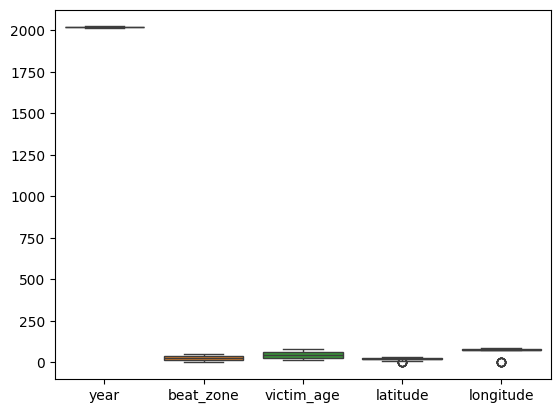

In [69]:
df_num=df.select_dtypes(include='number')
sns.boxplot(data=df_num)